# X-ray Density — Interactive Example Viewer

Select any PDB ID that has a downloaded CCP4 map and visualize its 2Fo-Fc electron
density aligned to the VoxBind 64³ pocket grid.

**Workflow**
1. Cell 1 — scan `dataset/data/ccp4/` and list available PDB IDs  
2. Cell 2 — pick a PDB ID  
3. Cell 3 — find a matching CrossDocked sample and load atom coords  
4. Cell 4 — load CCP4 map, crop 64³ density, visualize  

## 1. List Downloaded CCP4 Maps

In [1]:
import random
from pathlib import Path

import numpy as np
import torch

CCP4_DIR = Path("../voxbind/dataset/data/ccp4")
DATA_DIR = Path("../voxbind/dataset/data")

available = sorted(p.stem for p in CCP4_DIR.glob("*.map"))
print(f"Downloaded CCP4 maps : {len(available):,}")
print()

# Print in columns of 8
cols = 8
for i in range(0, min(len(available), 80), cols):
    print("  ".join(f"{p:6s}" for p in available[i:i+cols]))
if len(available) > 80:
    print(f"  ... and {len(available) - 80:,} more")

Downloaded CCP4 maps : 13,364

135l    14gs    1a0g    1a18    1a26    1a27    1a28    1a2d  
1a2g    1a2m    1a3y    1a4h    1a4l    1a4m    1a4r    1a4z  
1a53    1a5b    1a5p    1a95    1a96    1a97    1aa1    1ab0  
1aer    1af2    1afa    1ag8    1ai4    1aj6    1ajg    1ajs  
1ajv    1ajx    1ak5    1aln    1amh    1aod    1aqi    1aqj  
1aqp    1aqu    1arm    1as0    1as3    1asl    1at5    1at6  
1aus    1awb    1ax0    1axz    1azm    1azt    1b11    1b42  
1b57    1b5q    1b7y    1b93    1b9s    1b9t    1b9v    1ba0  
1ba1    1beu    1bg9    1bgq    1bh5    1bi5    1bju    1bjv  
1bk0    1bke    1bkw    1bky    1bpy    1bq6    1br5    1br6  
  ... and 13,284 more


## 2. Select a PDB ID

Edit `PDB_ID` below to any entry shown above.

In [21]:
PDB_ID = "14gs"   # ← change this

PDB_ID = PDB_ID.lower()
ccp4_path = CCP4_DIR / f"{PDB_ID}.map"

if not ccp4_path.exists():
    raise FileNotFoundError(
        f"No CCP4 map for '{PDB_ID}'. "
        f"Run scripts/06_download_xray.sh first, or pick an ID from Cell 1."
    )
print(f"Selected : {PDB_ID}  →  {ccp4_path}")

Selected : 14gs  →  ../voxbind/dataset/data/ccp4/14gs.map


## 3. Load Matching CrossDocked Sample

Searches `data_train.pt` then `data_test.pt` for the first sample whose PDB ID
matches the selection, then extracts pocket and ligand atom coordinates.

In [22]:
def get_pdb_id(pocket_id: str) -> str:
    return pocket_id.split("/")[1].split("_")[0].lower()


def find_sample(data_dir: Path, pdb_id: str):
    """Return (pocket_, ligand_) for the first sample matching pdb_id."""
    for pt_file in [data_dir / "data_train.pt", data_dir / "data_test.pt"]:
        if not pt_file.exists():
            continue
        data = torch.load(str(pt_file), weights_only=False)
        random.Random(1234).shuffle(data)          # same order as dataset class
        for pocket_, ligand_ in data:
            if get_pdb_id(pocket_["id"]) == pdb_id:
                return pocket_, ligand_, pt_file.stem
    return None, None, None


pocket_, ligand_, src = find_sample(DATA_DIR, PDB_ID)

if pocket_ is None:
    raise RuntimeError(
        f"PDB ID '{PDB_ID}' not found in CrossDocked data. "
        "It may exist in the CCP4 directory but not in the benchmark dataset."
    )

# Extract pocket atoms (C/O/N/S channels 0-3)
poc_mask   = pocket_["atoms_channel"] < 4
poc_coords = pocket_["coords"][poc_mask].numpy()      # (N, 3) absolute Å
poc_elems  = ["C", "O", "N", "S"][: 4]
poc_elem_per_atom = [
    ["C", "O", "N", "S"][int(c)] for c in pocket_["atoms_channel"][poc_mask]
]

# Extract ligand atoms and compute centroid
lig_mask   = ligand_["atoms_channel"] < 7
lig_coords = ligand_["coords"][lig_mask].numpy()      # (M, 3) absolute Å
centroid   = lig_coords.mean(axis=0)                  # (3,) ligand centroid

print(f"Source file     : {src}.pt")
print(f"Pocket ID       : {pocket_['id']}")
print(f"Pocket atoms    : {poc_coords.shape[0]}")
print(f"Ligand atoms    : {lig_coords.shape[0]}")
print(f"Ligand centroid : x={centroid[0]:.2f}  y={centroid[1]:.2f}  z={centroid[2]:.2f} Å")

Source file     : data_test.pt
Pocket ID       : GSTP1_HUMAN_2_210_0/14gs_A_rec_20gs_cbd_lig_tt_min_0_pocket10.pdb
Pocket atoms    : 255
Ligand atoms    : 22
Ligand centroid : x=24.26  y=6.69  z=27.79 Å


## 4. Load CCP4 Map + Crop 64³ Density

In [23]:
import gemmi
import scipy.ndimage

# ── Load CCP4 ─────────────────────────────────────────────────────────────
m = gemmi.read_ccp4_map(str(ccp4_path))
m.setup(float('nan'))          # populate grid from file data (required)
grid = m.grid
cell = grid.unit_cell

arr = np.array(grid, dtype=np.float32)   # shape: (nu, nv, nw)
nu, nv, nw = arr.shape
arr_norm = (arr - arr.mean()) / (arr.std() + 1e-10)

# Fractionalization matrix: invert the orthogonalization matrix (always available)
# cell.orth.mat converts fractional → Cartesian; its inverse goes Cartesian → fractional
orth_mat = np.array(cell.orth.mat.tolist())   # (3, 3)
frac_T   = np.linalg.inv(orth_mat).T          # (3,3), x @ frac_T = fractional coords

print(f"PDB ID      : {PDB_ID.upper()}")
print(f"Space group : {grid.spacegroup.hm}")
print(f"Unit cell   : a={cell.a:.2f}  b={cell.b:.2f}  c={cell.c:.2f} Å  "
      f"β={cell.beta:.2f}°")
print(f"Grid        : {nu} × {nv} × {nw}")
print(f"Map sigma   : {arr.std():.4f}")

PDB ID      : 14GS
Space group : C 1 2 1
Unit cell   : a=78.65  b=91.83  c=69.14 Å  β=98.25°
Grid        : 60 × 72 × 50
Map sigma   : 0.1973


In [24]:
# ── Crop 64³ VoxBind box around ligand centroid ───────────────────────────
VOXEL_RES = 0.25
GRID_SIZE  = 64
HALF       = VOXEL_RES * GRID_SIZE / 2   # 8 Å

grid_1d = (np.arange(GRID_SIZE, dtype=np.float32) - (GRID_SIZE - 1) / 2.0) * VOXEL_RES
gi, gj, gk = np.meshgrid(grid_1d, grid_1d, grid_1d, indexing="ij")

cart_pts = np.stack([
    (centroid[0] + gi).ravel(),
    (centroid[1] + gj).ravel(),
    (centroid[2] + gk).ravel(),
], axis=1)                                    # (G³, 3) absolute Å

# Cartesian → fractional (general, via gemmi fractionalization matrix)
frac_pts = cart_pts @ frac_T                  # (G³, 3)

# Fractional → continuous CCP4 grid indices (periodic wrap)
ci_q = (frac_pts[:, 0] * nu) % nu
cj_q = (frac_pts[:, 1] * nv) % nv
ck_q = (frac_pts[:, 2] * nw) % nw

# Trilinear interpolation with periodic boundary
density_64 = scipy.ndimage.map_coordinates(
    arr_norm, [ci_q, cj_q, ck_q], order=1, mode="wrap", prefilter=False
).reshape(GRID_SIZE, GRID_SIZE, GRID_SIZE)

d_sigma = density_64.std()
print(f"64³ density crop : mean={density_64.mean():.4f}  sigma={d_sigma:.4f}")
print(f"|ρ| ≥ 1σ points  : {(np.abs(density_64) >= d_sigma).sum():,} / {density_64.size:,}")

64³ density crop : mean=-0.0345  sigma=1.1661
|ρ| ≥ 1σ points  : 83,940 / 262,144


## 5. Visualize — Density Scatter + Pocket Atoms

In [25]:
import plotly.graph_objects as go

# ── Filter option ──────────────────────────────────────────────────────────
# "both"     → |ρ| ≥ 1σ  (positive and negative)
# "positive" → ρ ≥ +1σ   (2Fo-Fc electron presence)
# "negative" → ρ ≤ −1σ   (missing / displaced density)
DENSITY_FILTER = "both"   # ← change this

d_flat = density_64.ravel()
if DENSITY_FILTER == "positive":
    dmask = (d_flat >= 1.0 * d_sigma)
elif DENSITY_FILTER == "negative":
    dmask = (d_flat <= -1.0 * d_sigma)
else:
    dmask = (np.abs(d_flat) >= 1.0 * d_sigma)

Xd = gi.ravel()[dmask]
Yd = gj.ravel()[dmask]
Zd = gk.ravel()[dmask]
vals = d_flat[dmask]
clim = 2.0 * d_sigma

# ── Pocket atoms relative to ligand centroid ──────────────────────────────
ELEM_COL   = {"C": "silver", "N": "cornflowerblue", "O": "tomato", "S": "gold"}
poc_rel    = poc_coords - centroid
in_grid    = np.all(np.abs(poc_rel) <= HALF, axis=1)
poc_in     = poc_rel[in_grid]
elems_in   = [e for e, m in zip(poc_elem_per_atom, in_grid) if m]

# ── Ligand atoms relative to centroid ────────────────────────────────────
lig_rel = lig_coords - centroid

traces = []

# Density
traces.append(go.Scatter3d(
    x=Xd, y=Yd, z=Zd,
    mode="markers",
    marker=dict(
        size=2, color=vals,
        colorscale="RdBu", reversescale=True,
        cmin=-clim, cmax=clim, opacity=0.55,
        colorbar=dict(
            title="ρ", thickness=14, len=0.6,
            tickfont=dict(color="white"),
            # titlefont=dict(color="white"),
        ),
    ),
    name=f"density ({DENSITY_FILTER})",
    hovertemplate="Δx=%{x:.2f}<br>Δy=%{y:.2f}<br>Δz=%{z:.2f}<br>ρ=%{marker.color:.3f}<extra></extra>",
))

# Pocket atoms (one trace per element)
for elem in sorted(set(elems_in)):
    mask_e = np.array([e == elem for e in elems_in])
    xyz_e  = poc_in[mask_e]
    traces.append(go.Scatter3d(
        x=xyz_e[:, 0], y=xyz_e[:, 1], z=xyz_e[:, 2],
        mode="markers",
        marker=dict(size=5, color=ELEM_COL.get(elem, "purple"), opacity=0.9),
        name=f"pocket {elem}",
    ))

# Ligand atoms
traces.append(go.Scatter3d(
    x=lig_rel[:, 0], y=lig_rel[:, 1], z=lig_rel[:, 2],
    mode="markers",
    marker=dict(size=7, color="lime", symbol="diamond", opacity=0.95),
    name="ligand",
))

# Wireframe box (±8 Å boundary)
B = HALF
corners = np.array([
    [-B,-B,-B],[-B,-B,B],[-B,B,-B],[-B,B,B],
    [ B,-B,-B],[ B,-B,B],[ B,B,-B],[ B,B,B],
])
edges = [(0,1),(0,2),(1,3),(2,3),(4,5),(4,6),(5,7),(6,7),(0,4),(1,5),(2,6),(3,7)]
xs, ys, zs = [], [], []
for i, j in edges:
    xs += [corners[i,0], corners[j,0], None]
    ys += [corners[i,1], corners[j,1], None]
    zs += [corners[i,2], corners[j,2], None]
traces.append(go.Scatter3d(
    x=xs, y=ys, z=zs, mode="lines",
    line=dict(color="white", width=1.5, dash="dash"),
    name=f"VoxBind grid (±{B:.0f} Å)",
))

fig = go.Figure(traces)
fig.update_layout(
    title=(
        f"{PDB_ID.upper()} — density ({DENSITY_FILTER}) + pocket atoms  "
        f"({dmask.sum():,} density points | {in_grid.sum()} pocket atoms in grid)"
    ),
    legend=dict(x=0.01, y=0.99, font_color="white"),
    scene=dict(
        xaxis_title="ΔX (Å)", yaxis_title="ΔY (Å)", zaxis_title="ΔZ (Å)",
        aspectmode="cube",
        bgcolor="rgb(15,15,15)",
        xaxis=dict(showbackground=False, gridcolor="rgba(255,255,255,0.1)",
                   range=[-B-1, B+1]),
        yaxis=dict(showbackground=False, gridcolor="rgba(255,255,255,0.1)",
                   range=[-B-1, B+1]),
        zaxis=dict(showbackground=False, gridcolor="rgba(255,255,255,0.1)",
                   range=[-B-1, B+1]),
    ),
    paper_bgcolor="rgb(25,25,25)",
    font_color="white",
    width=900, height=750,
)
fig.show()

print(f"Density filter   : {DENSITY_FILTER}")
print(f"Points shown     : {dmask.sum():,} / {density_64.size:,}")
print(f"Pocket in grid   : {in_grid.sum()} / {len(poc_coords)} "
      f"({100*in_grid.sum()/max(len(poc_coords),1):.1f}%)")

Density filter   : both
Points shown     : 83,940 / 262,144
Pocket in grid   : 100 / 255 (39.2%)


## 6. 2D Orthogonal Slices

Three orthogonal planes through the 64³ density crop.  
Set `SLICE_X/Y/Z` (0–63) to move each plane; 32 = ligand centroid.

VoxBind grid : 64 × 64 × 64  (262,144 voxels,  0.25 Å/voxel)
CCP4 grid    : 60 × 72 × 50  (U × V × W)
Slices       : X=20 (-2.88 Å)  Y=8 (-5.88 Å)  Z=20 (-2.88 Å)


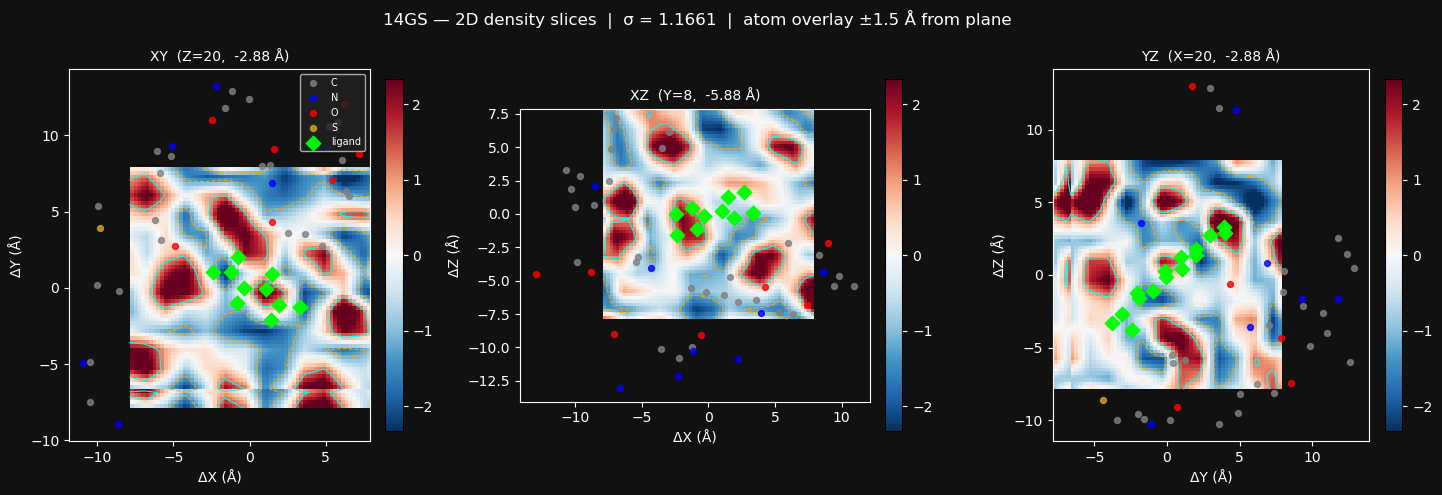

In [27]:
import matplotlib.pyplot as plt

# ── Slice parameters ─────────────────────────────────────────────────────────
SLICE_X = 20   # ← YZ plane: fix X index (0–63)
SLICE_Y = 8   # ← XZ plane: fix Y index (0–63)
SLICE_Z = 20   # ← XY plane: fix Z index (0–63)
NEAR_Å  = 1.5  # ← show pocket/ligand atoms within this distance of each slice plane

# ── Grid info ────────────────────────────────────────────────────────────────
G = GRID_SIZE
ticks = (np.arange(G) - (G - 1) / 2.0) * VOXEL_RES   # Å offsets per voxel

def idx_to_Å(idx):
    return (idx - (G - 1) / 2.0) * VOXEL_RES

print(f"VoxBind grid : {G} × {G} × {G}  ({G**3:,} voxels,  {VOXEL_RES} Å/voxel)")
print(f"CCP4 grid    : {nu} × {nv} × {nw}  (U × V × W)")
print(f"Slices       : X={SLICE_X} ({idx_to_Å(SLICE_X):+.2f} Å)  "
      f"Y={SLICE_Y} ({idx_to_Å(SLICE_Y):+.2f} Å)  "
      f"Z={SLICE_Z} ({idx_to_Å(SLICE_Z):+.2f} Å)")

# ── Atom coords relative to centroid ─────────────────────────────────────────
poc_rel = poc_coords - centroid
lig_rel = lig_coords - centroid
ELEM_COL = {"C": "gray", "N": "blue", "O": "red", "S": "goldenrod"}
clim = 2.0 * d_sigma

# (title, slice_array, horiz, vert, out-of-plane,  lig_h, lig_v, lig_oop,  xlabel, ylabel)
specs = [
    (f"XY  (Z={SLICE_Z},  {idx_to_Å(SLICE_Z):+.2f} Å)",
     density_64[:, :, SLICE_Z],
     poc_rel[:, 0], poc_rel[:, 1], poc_rel[:, 2],
     lig_rel[:, 0], lig_rel[:, 1], lig_rel[:, 2],
     "ΔX (Å)", "ΔY (Å)"),
    (f"XZ  (Y={SLICE_Y},  {idx_to_Å(SLICE_Y):+.2f} Å)",
     density_64[:, SLICE_Y, :],
     poc_rel[:, 0], poc_rel[:, 2], poc_rel[:, 1],
     lig_rel[:, 0], lig_rel[:, 2], lig_rel[:, 1],
     "ΔX (Å)", "ΔZ (Å)"),
    (f"YZ  (X={SLICE_X},  {idx_to_Å(SLICE_X):+.2f} Å)",
     density_64[SLICE_X, :, :],
     poc_rel[:, 1], poc_rel[:, 2], poc_rel[:, 0],
     lig_rel[:, 1], lig_rel[:, 2], lig_rel[:, 0],
     "ΔY (Å)", "ΔZ (Å)"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor("#111111")

for ax, (title, slc, px, py, pz, lx, ly, lz, xl, yl) in zip(axes, specs):
    im = ax.imshow(
        slc.T, origin="lower", cmap="RdBu_r",
        vmin=-clim, vmax=clim, aspect="equal",
        extent=[ticks[0], ticks[-1], ticks[0], ticks[-1]],
    )
    ax.contour(ticks, ticks, slc.T, levels=[ d_sigma],
               colors=["cyan"],   linewidths=0.8)
    ax.contour(ticks, ticks, slc.T, levels=[-d_sigma],
               colors=["orange"], linewidths=0.8, linestyles="dashed")

    # Pocket atoms near this slice plane
    near_poc = np.abs(pz) <= NEAR_Å
    for elem in sorted(set(poc_elem_per_atom)):
        emask = np.array([e == elem for e in poc_elem_per_atom]) & near_poc
        if emask.any():
            ax.scatter(px[emask], py[emask],
                       c=ELEM_COL.get(elem, "purple"), s=18,
                       alpha=0.8, label=elem, zorder=3)

    # Ligand atoms near this slice plane
    near_lig = np.abs(lz) <= NEAR_Å
    if near_lig.any():
        ax.scatter(lx[near_lig], ly[near_lig],
                   c="lime", s=55, marker="D", alpha=0.95, label="ligand", zorder=4)

    ax.set_facecolor("#111111")
    ax.set_title(title, color="white", fontsize=10)
    ax.set_xlabel(xl, color="white")
    ax.set_ylabel(yl, color="white")
    ax.tick_params(colors="white")
    for sp in ax.spines.values():
        sp.set_edgecolor("white")
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(labelcolor="white", color="white")

axes[0].legend(fontsize=7, loc="upper right",
               facecolor="#222222", labelcolor="white")
fig.suptitle(
    f"{PDB_ID.upper()} — 2D density slices  |  σ = {d_sigma:.4f}  |  "
    f"atom overlay ±{NEAR_Å} Å from plane",
    color="white", fontsize=12,
)
plt.tight_layout()
plt.show()